Student Name : Jyoti Vijay Natlekar

Batch : CS2

Roll Number :CS38


### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
df = pd.read_csv("brca.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Display dataset information
print("\nDataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nColumn Names:")
print(df.columns)

First 5 rows of the dataset:
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1         13.540           14.36             87.46        566.3   
1           2         13.080           15.71             85.63        520.0   
2           3          9.504           12.44             60.34        273.9   
3           4         13.030           18.42             82.61        523.8   
4           5          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0            0.047810           0.1885  ...            19.2

# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [ ]:
print("\nDiagnosis Class Distribution:")
print(df['y'].value_counts())

# 5. Diagnosis distribution in percentage
print("\nDiagnosis Class Distribution (%):")
print(df['y'].value_counts(normalize=True) * 100)


Diagnosis Class Distribution:
y
B    357
M    212
Name: count, dtype: int64

Diagnosis Class Distribution (%):
y
B    62.741652
M    37.258348
Name: proportion, dtype: float64


# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
# Task 3: Preprocess and Scale Features

from sklearn.preprocessing import StandardScaler

# Select numerical features
X = df.drop(['Unnamed: 0', 'y'], axis=1)

# Store diagnosis separately as target variable
y = df['y']

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display results
print("Original Feature Dimensions:", X.shape)
print("Scaled Feature Dimensions:", X_scaled.shape)

print("\nFirst 5 rows of scaled features:")
print(X_scaled.head())

print("\nMean of scaled features:")
print(X_scaled.mean().round(2))

print("\nStandard deviation of scaled features:")
print(X_scaled.std().round(2))

Original Feature Dimensions: (569, 30)
Scaled Feature Dimensions: (569, 30)

First 5 rows of scaled features:
   x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0      -0.166799       -1.147162         -0.185728    -0.251957   
1      -0.297446       -0.833008         -0.261106    -0.383638   
2      -1.313080       -1.593959         -1.302806    -1.083572   
3      -0.311646       -0.202373         -0.385500    -0.372831   
4      -1.684571       -0.570050         -1.658278    -1.288347   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0           0.101747           -0.436850         -0.278210   
1           0.792763            0.429422         -0.541362   
2           0.429819           -0.747086         -0.743748   
3          -0.464730           -1.263703         -0.793214   
4          -0.737294           -0.851130         -0.915500   

   x.concave_pts_mean  x.symmetry_mean  x.fractal_dim_mean  ...  \
0           -0.028609         0.267911         

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
# Task 4: Construct Pairwise Distance Matrix & Graph

from scipy.spatial.distance import pdist, squareform
import networkx as nx

# Compute pairwise Euclidean distances
distance_matrix = squareform(pdist(X_scaled, metric='euclidean'))

# Display distance matrix dimensions
print("Distance Matrix Shape:", distance_matrix.shape)

# Display first 5x5 portion of distance matrix
print("\nFirst 5x5 Distance Matrix:")
print(distance_matrix[:5, :5])

# Create a weighted complete graph
G = nx.complete_graph(len(X_scaled))

# Add Euclidean distances as edge weights
for i, j in G.edges():
    G[i][j]['weight'] = distance_matrix[i, j]

# Display graph information
print("\nGraph Information:")
print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

Distance Matrix Shape: (569, 569)

First 5x5 Distance Matrix:
[[0.         3.10724668 3.62314178 5.20448164 4.46708561]
 [3.10724668 0.         4.01027585 5.62302017 4.37098277]
 [3.62314178 4.01027585 0.         5.12193591 2.94839575]
 [5.20448164 5.62302017 5.12193591 0.         5.02798792]
 [4.46708561 4.37098277 2.94839575 5.02798792 0.        ]]

Graph Information:
Number of Nodes: 569
Number of Edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
# Task 5: Compute the Minimum Spanning Tree (MST)

# Compute the Minimum Spanning Tree
MST = nx.minimum_spanning_tree(G, weight='weight')

# Display MST information
print("Minimum Spanning Tree (MST)")
print("Number of Nodes:", MST.number_of_nodes())
print("Number of Edges:", MST.number_of_edges())

# Extract MST connections and weights
print("\nMST Connections and Weights:")

for u, v, data in MST.edges(data=True):
    print(f"Node {u} -- Node {v} : Weight = {data['weight']:.4f}")

# Calculate total MST weight
total_weight = MST.size(weight='weight')

print("\nTotal MST Weight:", round(total_weight, 4))

Minimum Spanning Tree (MST)
Number of Nodes: 569
Number of Edges: 568

MST Connections and Weights:
Node 0 -- Node 81 : Weight = 1.6886
Node 0 -- Node 108 : Weight = 2.1714
Node 1 -- Node 105 : Weight = 1.6607
Node 2 -- Node 70 : Weight = 2.2189
Node 3 -- Node 170 : Weight = 2.3462
Node 3 -- Node 222 : Weight = 2.5415
Node 4 -- Node 279 : Weight = 1.8603
Node 4 -- Node 84 : Weight = 2.1660
Node 5 -- Node 125 : Weight = 1.7659
Node 5 -- Node 172 : Weight = 2.0171
Node 6 -- Node 336 : Weight = 1.4204
Node 6 -- Node 393 : Weight = 1.6933
Node 7 -- Node 140 : Weight = 1.7730
Node 8 -- Node 66 : Weight = 1.5108
Node 9 -- Node 126 : Weight = 1.5756
Node 9 -- Node 192 : Weight = 1.6264
Node 9 -- Node 95 : Weight = 1.6729
Node 10 -- Node 126 : Weight = 1.7781
Node 11 -- Node 140 : Weight = 1.3252
Node 11 -- Node 192 : Weight = 1.8396
Node 12 -- Node 322 : Weight = 1.9960
Node 13 -- Node 191 : Weight = 3.1979
Node 13 -- Node 247 : Weight = 3.2457
Node 14 -- Node 16 : Weight = 2.7457
Node 15 -- 

# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
# Task 6: Implement Graph-Based Clustering (K = 2)

# Set number of clusters
K = 2

# Create a copy of the MST
cluster_graph = MST.copy()

# Sort MST edges by weight in descending order
sorted_edges = sorted(
    cluster_graph.edges(data=True),
    key=lambda x: x[2]['weight'],
    reverse=True
)

# Remove the largest K-1 edges
edges_to_remove = sorted_edges[:K-1]

for u, v, data in edges_to_remove:
    cluster_graph.remove_edge(u, v)

# Find connected components
components = list(nx.connected_components(cluster_graph))

# Assign cluster labels
cluster_labels = np.zeros(len(X_scaled), dtype=int)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

# Display results
print("Number of Clusters:", len(components))

print("\nCluster Sizes:")
for cluster_id in range(K):
    print(f"Cluster {cluster_id}: {np.sum(cluster_labels == cluster_id)} samples")

# Display the removed edge
print("\nRemoved Edge:")
for u, v, data in edges_to_remove:
    print(f"Node {u} -- Node {v} : Weight = {data['weight']:.4f}")

# Display first 20 cluster labels
print("\nFirst 20 Cluster Labels:")
print(cluster_labels[:20])

Number of Clusters: 2

Cluster Sizes:
Cluster 0: 567 samples
Cluster 1: 2 samples

Removed Edge:
Node 544 -- Node 553 : Weight = 12.2999

First 20 Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
# Task 7: Evaluate MST Clustering Performance

from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

# Convert diagnosis labels into numerical labels
# B = 0, M = 1
true_labels = df['y'].map({'B': 0, 'M': 1}).values

# 1. Silhouette Score
silhouette = silhouette_score(X_scaled, cluster_labels)

# 2. Adjusted Rand Index (ARI)
ari = adjusted_rand_score(true_labels, cluster_labels)

# 3. Normalized Mutual Information (NMI)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)

# Display results
print("MST Clustering Performance")
print("--------------------------")
print("Silhouette Score:", round(silhouette, 4))
print("Adjusted Rand Index (ARI):", round(ari, 4))
print("Normalized Mutual Information (NMI):", round(nmi, 4))

MST Clustering Performance
--------------------------
Silhouette Score: 0.6607
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

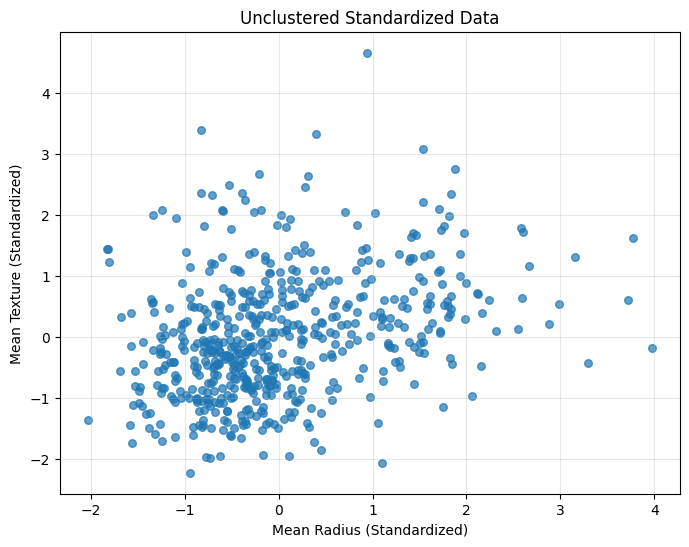

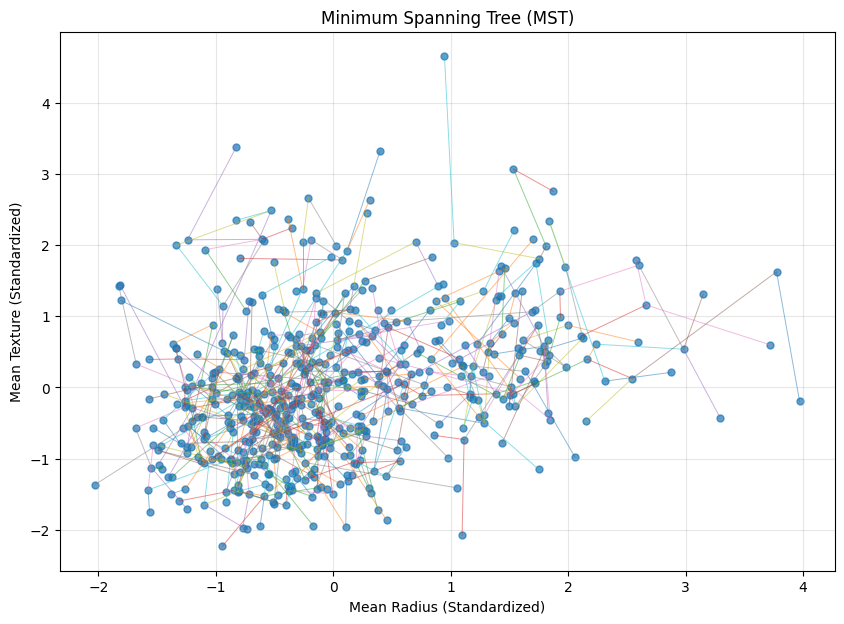

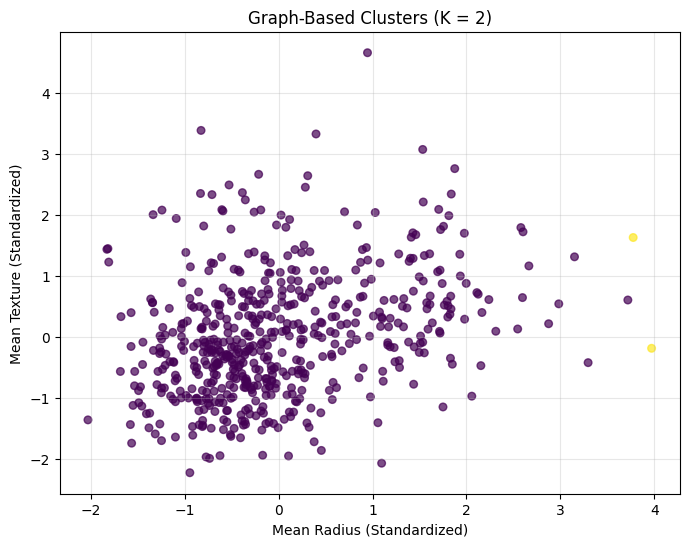

In [ ]:
# Task 8: Visualize MST and Graph-Based Clusters

import matplotlib.pyplot as plt

# Select two representative standardized features
feature_x = 'x.radius_mean'
feature_y = 'x.texture_mean'

x_index = X_scaled.columns.get_loc(feature_x)
y_index = X_scaled.columns.get_loc(feature_y)

x = X_scaled[feature_x].values
y_plot = X_scaled[feature_y].values


# ---------------------------------------------------------
# Plot 1: Unclustered Standardized Data
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y_plot,
    s=30,
    alpha=0.7
)

plt.xlabel('Mean Radius (Standardized)')
plt.ylabel('Mean Texture (Standardized)')
plt.title('Unclustered Standardized Data')
plt.grid(True, alpha=0.3)

plt.show()


# ---------------------------------------------------------
# Plot 2: MST Edge Connections
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# Plot data points
plt.scatter(
    x,
    y_plot,
    s=25,
    alpha=0.7
)

# Draw MST edges
for u, v in MST.edges():
    plt.plot(
        [x[u], x[v]],
        [y_plot[u], y_plot[v]],
        linewidth=0.7,
        alpha=0.5
    )

plt.xlabel('Mean Radius (Standardized)')
plt.ylabel('Mean Texture (Standardized)')
plt.title('Minimum Spanning Tree (MST)')
plt.grid(True, alpha=0.3)

plt.show()


# ---------------------------------------------------------
# Plot 3: Final Graph-Based Clusters
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y_plot,
    c=cluster_labels,
    s=30,
    alpha=0.7
)

plt.xlabel('Mean Radius (Standardized)')
plt.ylabel('Mean Texture (Standardized)')
plt.title('Graph-Based Clusters (K = 2)')
plt.grid(True, alpha=0.3)

plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.